## Comparativo de Performance: CPU vs GPU com LSTM no TensorFlow

**Objetivo:** Este notebook mede e compara o tempo de treinamento de uma Rede Neural Recorrente (LSTM) em duas plataformas de hardware diferentes: GPU e CPU.

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
import numpy as np
import time
import matplotlib.pyplot as plt
import os

print(f"TensorFlow Version: {tf.__version__}")

2025-10-14 21:28:51.534070: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-14 21:28:51.576212: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/thiag/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
2025-10-14 21:28:52.405759: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-p

TensorFlow Version: 2.20.0


### Preparação dos Dados

Vamos usar o dataset IMDB, que contém 50.000 críticas de filmes para análise de sentimentos (positivo/negativo).

Limitaremos nosso vocabulário às 10.000 palavras mais frequentes e garantiremos que todas as sequências de texto tenham o mesmo comprimento (256 palavras) através de preenchimento (`padding`).

In [2]:
vocab_size = 10000
maxlen = 256
batch_size = 64

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

print(f"{len(x_train)} sequências de treino")
print(f"{len(x_test)} sequências de teste")

print("\nPreenchendo sequências (padding)...")
x_train = sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = sequence.pad_sequences(x_test, maxlen=maxlen)

print(f"Formato dos dados de treino: {x_train.shape}")
print(f"Formato dos dados de teste: {x_test.shape}")

25000 sequências de treino
25000 sequências de teste

Preenchendo sequências (padding)...
Formato dos dados de treino: (25000, 256)
Formato dos dados de teste: (25000, 256)


### Definição do Modelo LSTM

Para garantir uma comparação justa, criaremos o modelo dentro de uma função. Isso nos permite gerar uma instância nova e idêntica do modelo para cada teste (GPU e CPU), evitando qualquer viés.

In [3]:
def create_lstm_model():
    model = keras.Sequential(
        [
            keras.layers.Embedding(vocab_size, 128, input_length=maxlen),
            keras.layers.LSTM(64),
            keras.layers.Dense(1, activation="sigmoid"),
        ]
    )

    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

### Comparativo de Treinamento

Agora, vamos treinar o modelo em cada dispositivo e registrar o tempo.

In [4]:
training_times = {}

#### Treinamento na GPU

In [5]:
gpus = tf.config.list_physical_devices("GPU")
if not gpus:
    print("Nenhuma GPU encontrada. O teste da GPU será pulado.")
else:
    print(f"Encontrada(s) {len(gpus)} GPU(s). Iniciando treinamento...")

    # Cria um modelo novo para a GPU
    model_gpu = create_lstm_model()

    # Mede o tempo
    start_time = time.time()
    model_gpu.fit(
        x_train,
        y_train,
        epochs=3,
        batch_size=batch_size,
        validation_data=(x_test, y_test),
    )
    end_time = time.time()

    gpu_time = end_time - start_time
    training_times["GPU"] = gpu_time

    print(f"\nTempo de treinamento na GPU: {gpu_time:.2f} segundos")

Encontrada(s) 1 GPU(s). Iniciando treinamento...
Epoch 1/3


/home/thiag/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1760488135.321357    2809 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5518 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
2025-10-14 21:28:56.408529: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400


391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.8060 - loss: 0.4205 - val_accuracy: 0.8648 - val_loss: 0.3301
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9012 - loss: 0.2530 - val_accuracy: 0.8623 - val_loss: 0.3517
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9331 - loss: 0.1787 - val_accuracy: 0.8753 - val_loss: 0.3341

Tempo de treinamento na GPU: 31.89 segundos


#### Treinamento na CPU

Para forçar o treinamento na CPU, usaremos o gerenciador de contexto `tf.device('/CPU:0')`. Todo o código dentro deste bloco será executado na CPU.

In [6]:
print("Forçando o uso da CPU para o treinamento...")

with tf.device("/CPU:0"):
    # Cria um modelo novo para a CPU
    model_cpu = create_lstm_model()

    # Mede o tempo
    start_time = time.time()
    model_cpu.fit(
        x_train,
        y_train,
        epochs=3,
        batch_size=batch_size,
        validation_data=(x_test, y_test),
    )
    end_time = time.time()

    cpu_time = end_time - start_time
    training_times["CPU"] = cpu_time

    print(f"\nTempo de treinamento na CPU: {cpu_time:.2f} segundos")

Forçando o uso da CPU para o treinamento...
Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.8051 - loss: 0.4218 - val_accuracy: 0.8548 - val_loss: 0.3496
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.8925 - loss: 0.2746 - val_accuracy: 0.8707 - val_loss: 0.3357
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.9269 - loss: 0.1943 - val_accuracy: 0.8735 - val_loss: 0.3279

Tempo de treinamento na CPU: 36.15 segundos


### Resultados e Conclusão

Resultados
- Dispositivo: GPU   | Tempo:   31.89 segundos
- Dispositivo: CPU   | Tempo:   36.15 segundos

Conclusão: O treinamento na GPU foi aproximadamente 1.13 vezes mais rápido que na CPU.


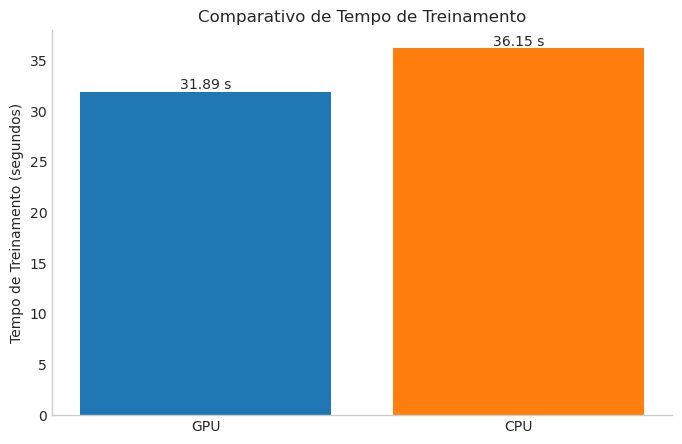

In [7]:
print("Resultados")
for device, duration in training_times.items():
    print(f"- Dispositivo: {device:<5} | Tempo: {duration:>7.2f} segundos")

if "GPU" in training_times and "CPU" in training_times:
    speedup = training_times["CPU"] / training_times["GPU"]
    print(
        f"\nConclusão: O treinamento na GPU foi aproximadamente {speedup:.2f} vezes mais rápido que na CPU."
    )
else:
    print(
        "\nNão foi possível calcular o ganho de performance pois um dos testes não foi executado."
    )

# Gerando o gráfico
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(8, 5))
devices = list(training_times.keys())
times = list(training_times.values())
bars = ax.bar(devices, times, color=["#1f77b4", "#ff7f0e"])

ax.set_title("Comparativo de Tempo de Treinamento")
ax.set_ylabel("Tempo de Treinamento (segundos)")
ax.bar_label(bars, fmt="%.2f s")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.grid(False)